This notebook runs segmentation using the tensorstore package for array storage.

In [1]:
import tracemalloc
from datetime import datetime
import torch
from matplotlib import pyplot as plt
import os
import ac_segmentation.neurotorch.datasets.dataset
from ac_segmentation.neurotorch.datasets.dataset import open_ZarrTensor, create_EmptyTensor
import ac_segmentation.neurotorch.core.predictor
import ac_segmentation.neurotorch.nets.RSUNet

Predictor = ac_segmentation.neurotorch.core.predictor.Predictor
Vector = ac_segmentation.neurotorch.datasets.datatypes.Vector
BoundingBox = ac_segmentation.neurotorch.datasets.datatypes.BoundingBox
TSArray = ac_segmentation.neurotorch.datasets.dataset.TSArray

In [2]:
##Open input tensor
in_arr = open_ZarrTensor('/ACdata/Users/kevin/ispim_ome_zarr/H17_x55_S39a_230808_highres/H17_x55_S39a_230808_highres.zarr/highres_Pos89/1/', bytes_limit= 100_000_000)
in_arr = in_arr[0,0,:,:,:].transpose()

##Create output tensor
out_arr = create_EmptyTensor('/ACdata/Users/connorl/this.zarr', in_arr.shape, dtype = 'int16')
out_arr.write(-1000).result()

In [3]:
checkpt_file = "/home/russelt/some_ckpt.ckpt"
net = ac_segmentation.neurotorch.nets.RSUNet.RSUNet()
predictor = Predictor(net, checkpt_file, gpu_device=None)

##Create input and output array objects
inarr = TSArray(in_arr, iteration_size=BoundingBox(Vector(0, 0, 0),Vector(32, 32, 32)), stride = Vector(64, 64, 64))
outarr = TSArray(out_arr)

##Run segmentation
torch.set_num_threads(56) 
predictor.run(inarr, outarr, batch_size=100, max_pix = 30000)

##Calculate probability map and output in a variety of ways
prob_map = outarr.getProbMap() #output is array
outarr.outputProbMap('/home/connor.laughland/Documents/Seg_Skel/', type='zarr') #output is zarr, hdf5, or tiff

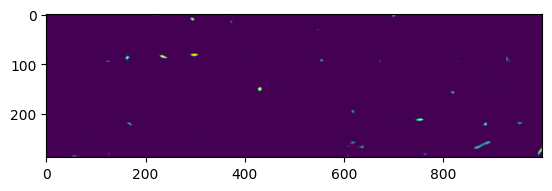

In [7]:
plt.imshow(prob_map[140, :, 12000:13000])